## LOGISTIC REGRESSION ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('./data/airline.csv')

In [3]:
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [4]:
c_map = {"Loyal Customer":1, "disloyal Customer":2}
df["Customer Type"] =   df["Customer Type"].map(c_map)

In [5]:

ttype_map = {"Personal Travel":1, "Business Travel":2}
df["Type of Travel"] =   df["Type of Travel"].map(ttype_map).astype("Int64")

In [6]:
ctype_map = {"Eco":1, "Business":2, "Eco Plus" : 3}
df["Class"] =  df["Class"].map(ctype_map)

In [7]:
df = df.drop(["Type of Travel"], axis=1)

In [8]:
df = df.dropna()

In [9]:
df.head()

,satisfaction,Customer Type,Age,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,1,65,1,265,0,0,0,2,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,1,47,2,2464,0,0,0,3,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,1,15,1,2138,0,0,0,3,2,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,1,60,1,623,0,0,0,3,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,1,70,1,354,0,0,0,3,4,...,4,2,2,0,2,4,2,5,0,0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129487 non-null  object 
 1   Customer Type                      129487 non-null  int64  
 2   Age                                129487 non-null  int64  
 3   Class                              129487 non-null  int64  
 4   Flight Distance                    129487 non-null  int64  
 5   Seat comfort                       129487 non-null  int64  
 6   Departure/Arrival time convenient  129487 non-null  int64  
 7   Food and drink                     129487 non-null  int64  
 8   Gate location                      129487 non-null  int64  
 9   Inflight wifi service              129487 non-null  int64  
 10  Inflight entertainment             129487 non-null  int64  
 11  Online support                     129487 no

In [12]:
df.shape

(129487, 21)

## Examining The Satisfation

In [13]:
df["satisfaction"]

0            satisfied
1            satisfied
2            satisfied
3            satisfied
4            satisfied
              ...     
129875       satisfied
129876    dissatisfied
129877    dissatisfied
129878    dissatisfied
129879    dissatisfied
Name: satisfaction, Length: 129487, dtype: object

In [14]:
vc = df["satisfaction"].value_counts(normalize=True).sort_index()

## Visualization

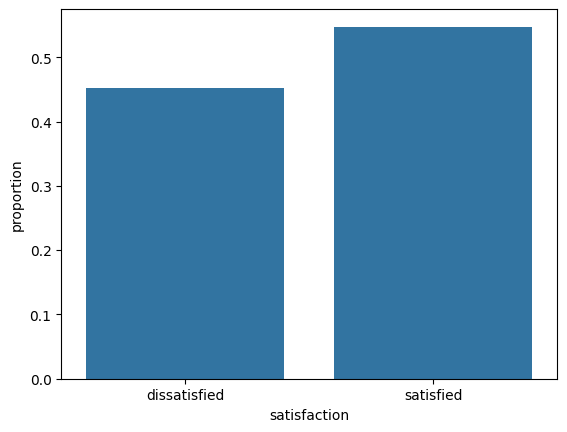

In [15]:
sns.barplot(vc) # visualization of customer satisfaction
plt.savefig("./images/bar.png", dpi=300)
plt.show();

In [16]:
y = df["satisfaction"]
X = df.drop(columns=["satisfaction"])

# Multicolinearity

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

print(vif)

                              Feature        VIF
0                       Customer Type   8.547260
1                                 Age   7.409781
2                               Class   8.042769
3                     Flight Distance   4.754305
4                        Seat comfort  12.436316
5   Departure/Arrival time convenient   8.456782
6                      Food and drink  13.458963
7                       Gate location  10.445465
8               Inflight wifi service  14.014298
9              Inflight entertainment  13.465133
10                     Online support  19.257726
11             Ease of Online booking  30.329898
12                   On-board service  15.001495
13                   Leg room service  11.302441
14                   Baggage handling  21.451331
15                    Checkin service   9.646325
16                        Cleanliness  22.873049
17                    Online boarding  20.641932
18         Departure Delay in Minutes  16.854118
19           Arrival

In [18]:
set_map = {"dissatisfied":0, "satisfied":1}
y = y.map(set_map)

In [19]:
X_train, X_test, y_train, y_test =  train_test_split(X,y, test_size=0.2, random_state=42)

In [20]:
model = LogisticRegression(max_iter=1000)

In [21]:
model.fit(X_train, y_train)

/home/henorh/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [22]:
y_pred = model.predict(X_test)

In [23]:
ac_score =accuracy_score(y_test, y_pred)

In [24]:
ac_score

0.8045795042088192

In [25]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.2f}")

F1 Score: 0.82


In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 8984  2837]
 [ 2224 11853]]


In [27]:
clr = classification_report(y_test, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       0.80      0.76      0.78     11821
           1       0.81      0.84      0.82     14077

    accuracy                           0.80     25898
   macro avg       0.80      0.80      0.80     25898
weighted avg       0.80      0.80      0.80     25898



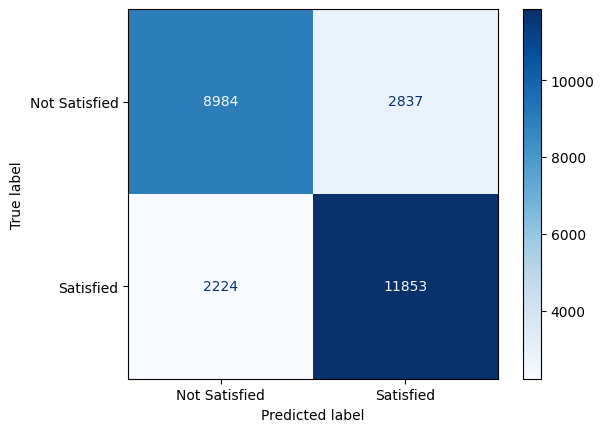

In [28]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Satisfied', 'Satisfied'])
cmd.plot(cmap='Blues')
plt.savefig("./images/cmap.png", dpi=300)
plt.show()

In [29]:
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
})